In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio.mask import mask

In [40]:
# sampling rate
sr = 50
# sampling interval
ts = 1.0/sr
t = np.arange(0,1,ts)

In [44]:
# --
#T_02 = 1 # Tengo que normalizar por la cantidad de puntos (t)
f_02 = 1 #
omega_02 = 2*np.pi*f_02 #Tengo que normalizar por la cantidad de puntos (t)
cos_02 =np.cos(omega_02*t)

# --
f_03 = 2
omega_03 = 2*np.pi*f_03
cos_03 =np.cos(omega_03*t)

# --
n = 7
f_04 = n
omega_04 = 2*np.pi*f_04
cos_04 =np.cos(omega_04*t)

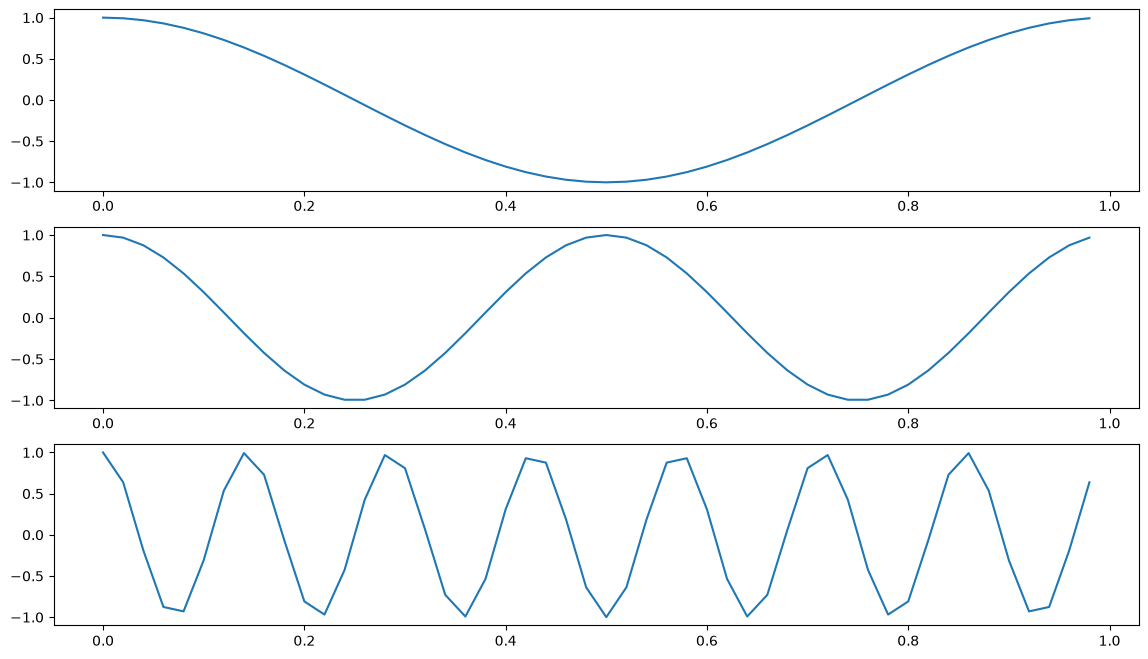

In [45]:
fig, ax = plt.subplots(3, 1, figsize=(14, 8))

ax[0].plot(t, cos_02)

ax[1].plot(t, cos_03)

ax[2].plot(t, cos_04)

In [46]:
# Suma de los cosenos
cos_sum = cos_02 + cos_03 + cos_04

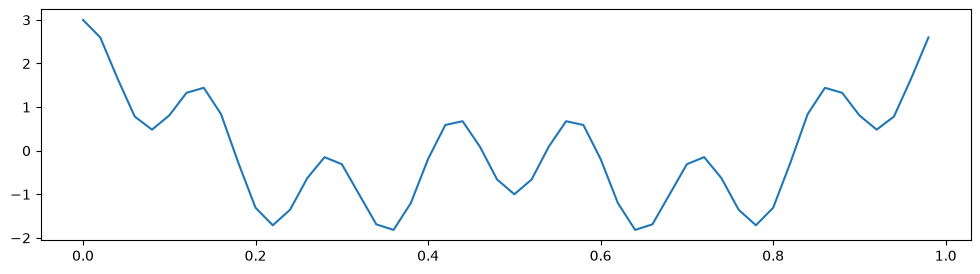

In [47]:
fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(t, cos_sum)

### --

In [53]:
def DFT(x):
    """
    Function to calculate the 
    discrete Fourier Transform 
    of a 1D real-valued signal x
    """

    N = len(x)
    n = np.arange(N)
    k = n.reshape((N, 1))
    e = np.exp(-2j * np.pi * k * n / N)
    
    X = np.dot(e, x)
    
    return X


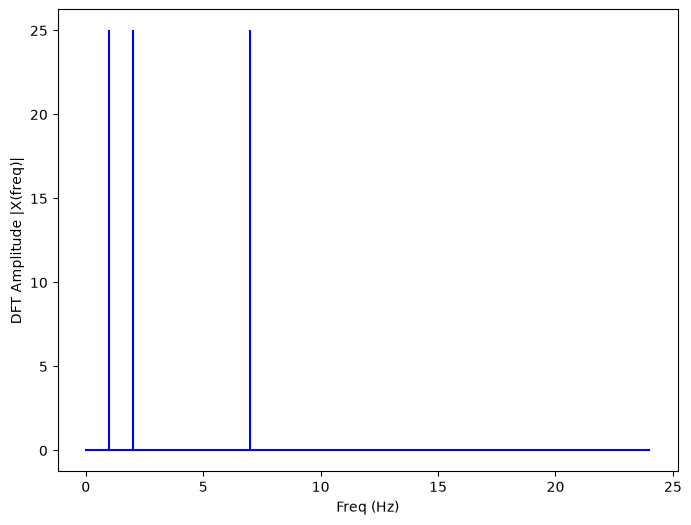

In [51]:
X = DFT(cos_sum)

# calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T 

plt.figure(figsize = (8, 6))
plt.stem(freq[:sr//2], abs(X)[:sr//2], 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.show()

### ---

In [3]:
dfLoaded = pd.read_csv('modis_ndvi_series_BBSS07.csv').drop(columns=['system:index', '.geo'])

listDates = list(dfLoaded.columns)
listSamples = list(dfLoaded['Cobertura'])

matrixNDVISamples = dfLoaded.iloc[:, :-1].to_numpy()

matrixNDVISamples = matrixNDVISamples*10000

#-------------------------------------------------------------------------------

dfNDVITransver = pd.DataFrame()

i = 0

for s in listSamples:
  dfNDVITransver[s] = matrixNDVISamples[i, :]
  i += 1

dfNDVITransver['Fecha'] = listDates[:-1]

dfNDVITransver['Fecha'] = pd.to_datetime(dfNDVITransver['Fecha'], format='%Y_%m_%d') #'%m/%d/%Y'

/tmp/ipykernel_13924/1392173588.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfNDVITransver[s] = matrixNDVISamples[i, :]
/tmp/ipykernel_13924/1392173588.py:20: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  dfNDVITransver['Fecha'] = listDates[:-1]


In [8]:
dfNDVITransver.sample(5)

,ArrocerasN1,ArrocerasN2,ArrocerasN3,ArrocerasN4,ArrocerasM1,ArrocerasM2,ArrocerasM3,ArrocerasM4,ArrocerasM5,ArrocerasS1,...,SabanasM2,SabanasM3,SabanasM4,SabanasM5,SabanasN1,SabanasN2,SabanasN3,SabanasN4,SabanasN5,Fecha
331,2600.0,3100.0,2700.0,2800.0,5000.0,2900.0,4300.0,5300.0,6300.0,3200.0,...,5700.0,6300.0,6200.0,5900.0,6700.0,6900.0,6500.0,6700.0,6300.0,2014-07-12
155,6400.0,4400.0,4400.0,4000.0,7000.0,5200.0,7000.0,6300.0,7000.0,5600.0,...,5700.0,5600.0,7500.0,7200.0,7100.0,6900.0,7600.0,7100.0,6900.0,2006-11-17
491,3800.0,3300.0,6100.0,4900.0,3600.0,5900.0,6200.0,6200.0,3400.0,3100.0,...,6000.0,5900.0,6400.0,6400.0,6700.0,6300.0,6000.0,5700.0,6100.0,2021-06-26
215,4000.0,2700.0,2400.0,2700.0,5400.0,2700.0,3500.0,2700.0,4600.0,3700.0,...,3600.0,4100.0,4200.0,4300.0,4400.0,4300.0,5600.0,4900.0,5000.0,2009-06-26
430,3100.0,5500.0,2700.0,4600.0,7500.0,6600.0,6300.0,5400.0,3400.0,3000.0,...,6700.0,6800.0,6900.0,6600.0,7800.0,6700.0,7800.0,7800.0,7300.0,2018-11-01


/tmp/ipykernel_13924/1920102799.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=10)


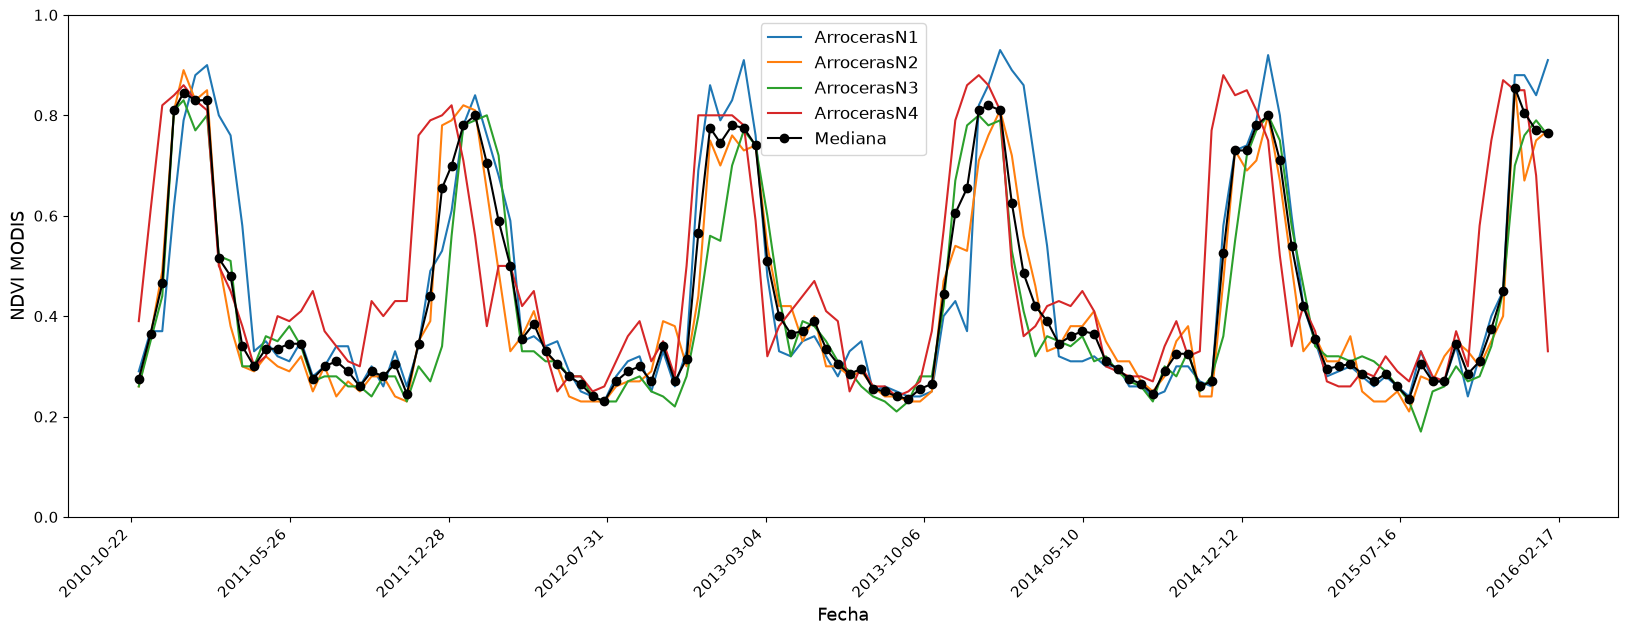

In [15]:
listArrocN = ['ArrocerasN1', 'ArrocerasN2', 'ArrocerasN3', 'ArrocerasN4']
startDateAN = '2010-10-22'
endDateAN = '2016-02-17'

dfNDVITransverFilt01 = dfNDVITransver.copy()

dfNDVITransverFilt01 = dfNDVITransverFilt01[(dfNDVITransverFilt01['Fecha'] >= startDateAN) & (dfNDVITransverFilt01['Fecha'] <= endDateAN)]

fig, axs = plt.subplots(figsize=(20, 6.52))#, sharex=True)

# --
list_data_arroc = []

for subS in list(listArrocN):
    
    axs.plot(dfNDVITransverFilt01['Fecha'],
        np.array(dfNDVITransverFilt01[subS])/10000, # Normalizo
        label=subS)
    
    # --
    list_data_arroc.append(np.array(dfNDVITransverFilt01[subS])/10000)
    
# --
array_arroc = np.array(list_data_arroc)
array_aroc_mean = np.nanmedian(array_arroc, axis=0)
#print(array_arroc.shape)
axs.plot(dfNDVITransverFilt01['Fecha'],
    array_aroc_mean,
    marker='o',
    linestyle=None,
    color='black',
    label='Mediana')

  
axs.set_ylabel('NDVI MODIS', fontsize=13)#'Burned area ['+r'$km^2$'+']', fontsize=15)
axs.set_xlabel('Fecha', fontsize=13)
axs.legend(fontsize=12, loc='best')

# Adjust the frequency of x-axis ticks
axs.xaxis.set_major_locator(plt.MultipleLocator(base=24*9))  # Adjust to desired frequency
axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=10)
axs.tick_params(axis='both', labelsize=11)

#axs[pos].set_xlim([-2000, 10000])
axs.set_ylim([0, 1])

plt.show()

In [16]:
len(array_aroc_mean)

122

In [69]:
np.arange(1, len(array_aroc_mean)*16, 16)

array([   1,   17,   33,   49,   65,   81,   97,  113,  129,  145,  161,
        177,  193,  209,  225,  241,  257,  273,  289,  305,  321,  337,
        353,  369,  385,  401,  417,  433,  449,  465,  481,  497,  513,
        529,  545,  561,  577,  593,  609,  625,  641,  657,  673,  689,
        705,  721,  737,  753,  769,  785,  801,  817,  833,  849,  865,
        881,  897,  913,  929,  945,  961,  977,  993, 1009, 1025, 1041,
       1057, 1073, 1089, 1105, 1121, 1137, 1153, 1169, 1185, 1201, 1217,
       1233, 1249, 1265, 1281, 1297, 1313, 1329, 1345, 1361, 1377, 1393,
       1409, 1425, 1441, 1457, 1473, 1489, 1505, 1521, 1537, 1553, 1569,
       1585, 1601, 1617, 1633, 1649, 1665, 1681, 1697, 1713, 1729, 1745,
       1761, 1777, 1793, 1809, 1825, 1841, 1857, 1873, 1889, 1905, 1921,
       1937])

/tmp/ipykernel_13924/1202104085.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=10)


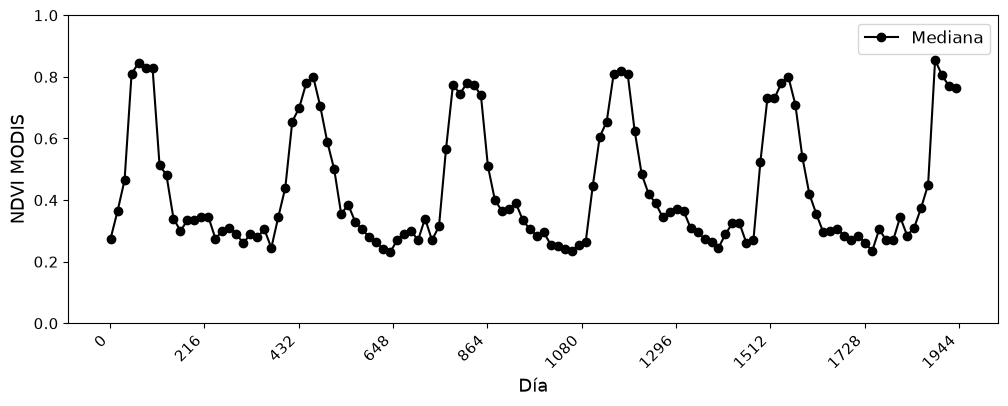

In [75]:
# --
ndvi_arroc_medn = array_aroc_mean
dates_count = np.arange(1, len(array_aroc_mean)*16+1, 16)

# --
fig, axs = plt.subplots(figsize=(12, 4))#, sharex=True)

# --
axs.plot(dates_count,
    ndvi_arroc_medn,
    marker='o',
    linestyle=None,
    color='black',
    label='Mediana')

  
axs.set_ylabel('NDVI MODIS', fontsize=13)#'Burned area ['+r'$km^2$'+']', fontsize=15)
axs.set_xlabel('Día', fontsize=13)
axs.legend(fontsize=12, loc='best')

# Adjust the frequency of x-axis ticks
axs.xaxis.set_major_locator(plt.MultipleLocator(base=24*9))  # Adjust to desired frequency
axs.set_xticklabels(axs.get_xticklabels(), rotation=45, ha='right', fontsize=10)
axs.tick_params(axis='both', labelsize=11)

axs.set_ylim([0, 1])

plt.show()

In [76]:
'''# sampling rate
sr = 16
# sampling interval
ts = 1.0/sr'''

# --
ts = 16
sr = (dates_count[-1]+16)/ts

In [55]:
sr//2

np.float64(61.0)

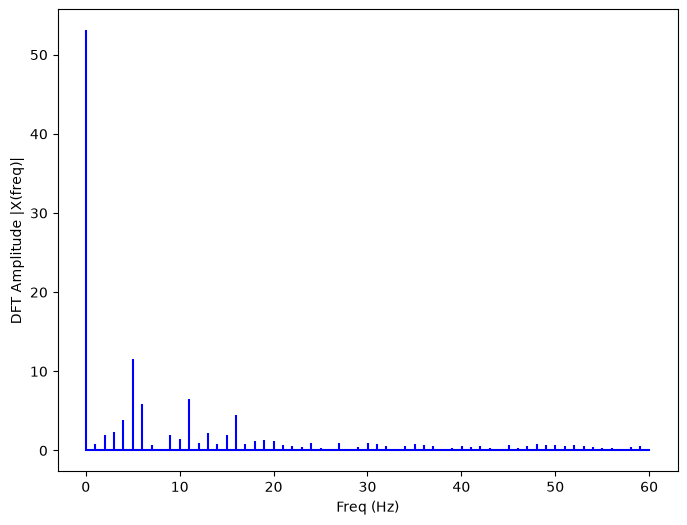

In [77]:
X = DFT(ndvi_arroc_medn)

# calculate the frequency
N = len(X)
n = np.arange(N)
T = N/sr
freq = n/T 

plt.figure(figsize = (8, 6))
plt.stem(freq[:int(sr//2)], abs(X)[:int(sr//2)], 'b', \
         markerfmt=" ", basefmt="-b")
plt.xlabel('Freq (Hz)')
plt.ylabel('DFT Amplitude |X(freq)|')
plt.show()

In [78]:
# --
idx_asc = np.argsort(abs(X)[:int(sr//2)][1:]) # ascending
larg_three = idx_asc[-3:]


In [79]:
freq[:int(sr//2)][larg_three]

array([ 5.00256148, 10.00512295,  4.00204918])